<a href="https://colab.research.google.com/github/abdulqn/portfolio/blob/main/nhs_gp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Healthcare Accessibility:** *A Geospatial and Machine Learning Approach to GP Service Distribution and Population in the West Midlands*

This study examines NHS general practitioner (GP) practices within three Integrated Care Boards (ICBs) in England, employing advanced geospatial analysis, demographic data, and machine learning models to address healthcare disparities. The study primarily focuses on the West Midlands Metropolitan area characterised by diverse urban and rural communities.

# **Required packages and Installation**


In [ ]:
# ----- Install Required Libraries -----

!pip install pandas geopandas openrouteservice scikit-learn xgboost


In [5]:
# ----- Import Required Libraries -----

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import shape
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import openrouteservice

# **Loading the datasets**

In [ ]:
# ----- Mount Google Drive -----
drive.mount('/content/drive')

# ----- File Paths -----
gp_data_path = '/content/drive/MyDrive/Datasets/nhs_gp/gp-reg-pat-prac-all.csv'
gp_loc_path = '/content/drive/MyDrive/Datasets/nhs_gp/gp-reg-pat-prac-map.csv'
lsoa_path = '/content/drive/MyDrive/Datasets/nhs_gp/lsoa_lookup.csv'
lsoa_boundary_path = '/content/drive/MyDrive/Datasets/nhs_gp/wm_lsoa.geojson'
nhs_postcodes_path = '/content/drive/MyDrive/Datasets/nhs_gp/nhs_postcodes.csv'
pop_path = '/content/drive/MyDrive/Datasets/nhs_gp/pop.csv'

# ----- Load Datasets -----
gp_data = pd.read_csv(gp_data_path)
gp_loc = pd.read_csv(gp_loc_path)
lsoa = pd.read_csv(lsoa_path)
lsoa_boundary = gpd.read_file(lsoa_boundary_path)
nhs_postcodes = pd.read_csv(nhs_postcodes_path)
pop = pd.read_csv(pop_path)

In [7]:
gp_data.head()

,PUBLICATION,EXTRACT_DATE,TYPE,SUB_ICB_LOCATION_CODE,ONS_SUB_ICB_LOCATION_CODE,CODE,POSTCODE,SEX,AGE,NUMBER_OF_PATIENTS
0,GP_PRAC_PAT_LIST,2024-12-01,GP,16C,E38000247,A81001,TS18 1HU,ALL,ALL,3888
1,GP_PRAC_PAT_LIST,2024-12-01,GP,16C,E38000247,A81002,TS18 2AW,ALL,ALL,18746
2,GP_PRAC_PAT_LIST,2024-12-01,GP,16C,E38000247,A81004,TS5 8SB,ALL,ALL,11330
3,GP_PRAC_PAT_LIST,2024-12-01,GP,16C,E38000247,A81005,TS14 7DJ,ALL,ALL,7743
4,GP_PRAC_PAT_LIST,2024-12-01,GP,16C,E38000247,A81006,TS18 2AT,ALL,ALL,14728


In [8]:
gp_loc.head()

,PUBLICATION,EXTRACT_DATE,PRACTICE_CODE,PRACTICE_NAME,PRACTICE_POSTCODE,PCN_CODE,PCN_NAME,ONS_SUB_ICB_LOCATION_CODE,SUB_ICB_LOCATION_CODE,SUB_ICB_LOCATION_NAME,ONS_ICB_CODE,ICB_CODE,ICB_NAME,ONS_COMM_REGION_CODE,COMM_REGION_CODE,COMM_REGION_NAME,SUPPLIER_NAME
0,GP_PRAC_PAT_LIST,01Dec2024,A81001,THE DENSHAM SURGERY,TS18 1HU,U89141,STOCKTON PCN,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E40000012,Y63,North East and Yorkshire,TPP
1,GP_PRAC_PAT_LIST,01Dec2024,A81002,QUEENS PARK MEDICAL CENTRE,TS18 2AW,U07032,NORTH STOCKTON PCN,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E40000012,Y63,North East and Yorkshire,TPP
2,GP_PRAC_PAT_LIST,01Dec2024,A81004,ACKLAM MEDICAL CENTRE,TS5 8SB,U02671,GREATER MIDDLESBROUGH PCN,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E40000012,Y63,North East and Yorkshire,TPP
3,GP_PRAC_PAT_LIST,01Dec2024,A81005,SPRINGWOOD SURGERY,TS14 7DJ,U07842,EAST CLEVELAND PCN,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E40000012,Y63,North East and Yorkshire,TPP
4,GP_PRAC_PAT_LIST,01Dec2024,A81006,TENNANT STREET MEDICAL PRACTICE,TS18 2AT,U07032,NORTH STOCKTON PCN,E38000247,16C,NHS North East and North Cumbria ICB - 16C,E54000050,QHM,NHS North East and North Cumbria Integrated Ca...,E40000012,Y63,North East and Yorkshire,TPP


In [9]:
print(gp_loc['COMM_REGION_NAME'].unique())

print(gp_loc['ICB_NAME'].unique())

['North East and Yorkshire' 'North West' 'Midlands' 'East of England'
 'London' 'South East' 'South West']
['NHS North East and North Cumbria Integrated Care Board'
 'NHS Lancashire and South Cumbria Integrated Care Board'
 'NHS Humber and North Yorkshire Integrated Care Board'
 'NHS West Yorkshire Integrated Care Board'
 'NHS Derby and Derbyshire Integrated Care Board'
 'NHS Staffordshire and Stoke-on-Trent Integrated Care Board'
 'NHS Leicester, Leicestershire and Rutland Integrated Care Board'
 'NHS Nottingham and Nottinghamshire Integrated Care Board'
 'NHS Lincolnshire Integrated Care Board'
 'NHS South Yorkshire Integrated Care Board'
 'NHS Cambridgeshire and Peterborough Integrated Care Board'
 'NHS Hertfordshire and West Essex Integrated Care Board'
 'NHS Norfolk and Waveney Integrated Care Board'
 'NHS Suffolk and North East Essex Integrated Care Board'
 'NHS Bedfordshire, Luton and Milton Keynes Integrated Care Board'
 'NHS North Central London Integrated Care Board'
 'NHS No

In [10]:
# List of ICB names to filter by
icb_names_to_filter = [
    'NHS Coventry and Warwickshire Integrated Care Board',
    'NHS Birmingham and Solihull Integrated Care Board',
    'NHS Black Country Integrated Care Board'
]

# Filter the data based on the 'ICB_NAME' column
filtered_gp_loc = gp_loc[gp_loc['ICB_NAME'].isin(icb_names_to_filter)]

# Display the filtered data
print(filtered_gp_loc)

           PUBLICATION EXTRACT_DATE PRACTICE_CODE  \
4657  GP_PRAC_PAT_LIST    01Dec2024        M84001   
4658  GP_PRAC_PAT_LIST    01Dec2024        M84002   
4659  GP_PRAC_PAT_LIST    01Dec2024        M84003   
4660  GP_PRAC_PAT_LIST    01Dec2024        M84004   
4661  GP_PRAC_PAT_LIST    01Dec2024        M84005   
...                ...          ...           ...   
6187  GP_PRAC_PAT_LIST    01Dec2024        Y04965   
6189  GP_PRAC_PAT_LIST    01Dec2024        Y04969   
6213  GP_PRAC_PAT_LIST    01Dec2024        Y05826   
6218  GP_PRAC_PAT_LIST    01Dec2024        Y06218   
6222  GP_PRAC_PAT_LIST    01Dec2024        Y06378   

                       PRACTICE_NAME PRACTICE_POSTCODE PCN_CODE  \
4657               RED ROOFS SURGERY          CV11 5TW   U92562   
4658             POOL MEDICAL CENTRE           B80 7QU   U55724   
4659           ARBURY MEDICAL CENTRE          CV10 8LW   U92562   
4660      WHITEHALL MEDICAL PRACTICE          CV21 3AQ   U62213   
4661              CHAPEL END

In [11]:
print("Null values in each column:")
print(filtered_gp_loc.isnull().sum())
print("\n----------------------\n")

print("Number of duplicated rows:")
print(filtered_gp_loc.duplicated().sum())
print("\n----------------------\n")

print("Dataframe Info:")
filtered_gp_loc.info()
print("\n----------------------\n")

print("Shape of the DataFrame:")
print(filtered_gp_loc.shape)

Null values in each column:
PUBLICATION                  0
EXTRACT_DATE                 0
PRACTICE_CODE                0
PRACTICE_NAME                0
PRACTICE_POSTCODE            0
PCN_CODE                     0
PCN_NAME                     0
ONS_SUB_ICB_LOCATION_CODE    0
SUB_ICB_LOCATION_CODE        0
SUB_ICB_LOCATION_NAME        0
ONS_ICB_CODE                 0
ICB_CODE                     0
ICB_NAME                     0
ONS_COMM_REGION_CODE         0
COMM_REGION_CODE             0
COMM_REGION_NAME             0
SUPPLIER_NAME                0
dtype: int64

----------------------

Number of duplicated rows:
0

----------------------

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
Index: 469 entries, 4657 to 6222
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   PUBLICATION                469 non-null    object
 1   EXTRACT_DATE               469 non-null    object
 2   PRACTICE

In [12]:
# Merge the two DataFrames by PRACTICE_POSTCODE
merged_df = pd.merge(filtered_gp_loc, nhs_postcodes, on='PRACTICE_POSTCODE', how='left')

# Create geometry from latitude and longitude
merged_df['geometry'] = merged_df.apply(lambda row: Point(row['Latitude'], row['Longitude']), axis=1)

# Convert to GeoDataFrame
geo_df = gpd.GeoDataFrame(merged_df, geometry='geometry')

# Display the result
print(geo_df)

          PUBLICATION EXTRACT_DATE PRACTICE_CODE  \
0    GP_PRAC_PAT_LIST    01Dec2024        M84001   
1    GP_PRAC_PAT_LIST    01Dec2024        M84002   
2    GP_PRAC_PAT_LIST    01Dec2024        M84003   
3    GP_PRAC_PAT_LIST    01Dec2024        M84004   
4    GP_PRAC_PAT_LIST    01Dec2024        M84005   
..                ...          ...           ...   
464  GP_PRAC_PAT_LIST    01Dec2024        Y04965   
465  GP_PRAC_PAT_LIST    01Dec2024        Y04969   
466  GP_PRAC_PAT_LIST    01Dec2024        Y05826   
467  GP_PRAC_PAT_LIST    01Dec2024        Y06218   
468  GP_PRAC_PAT_LIST    01Dec2024        Y06378   

                      PRACTICE_NAME PRACTICE_POSTCODE PCN_CODE  \
0                 RED ROOFS SURGERY          CV11 5TW   U92562   
1               POOL MEDICAL CENTRE           B80 7QU   U55724   
2             ARBURY MEDICAL CENTRE          CV10 8LW   U92562   
3        WHITEHALL MEDICAL PRACTICE          CV21 3AQ   U62213   
4                CHAPEL END SURGERY          

In [13]:
points = [Point(x, y) for x, y in zip(merged_df['easting'], merged_df['northing'])]

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(merged_df, geometry=points)

# Set CRS to British National Grid (EPSG:27700)
gdf.set_crs("EPSG:27700", inplace=True)

,PUBLICATION,EXTRACT_DATE,PRACTICE_CODE,PRACTICE_NAME,PRACTICE_POSTCODE,PCN_CODE,PCN_NAME,ONS_SUB_ICB_LOCATION_CODE,SUB_ICB_LOCATION_CODE,SUB_ICB_LOCATION_NAME,...,ICB_NAME,ONS_COMM_REGION_CODE,COMM_REGION_CODE,COMM_REGION_NAME,SUPPLIER_NAME,easting,northing,Latitude,Longitude,geometry
0,GP_PRAC_PAT_LIST,01Dec2024,M84001,RED ROOFS SURGERY,CV11 5TW,U92562,NUNEATON & BEDWORTH PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,436236,291378,52.519085,-1.467412,POINT (436236 291378)
1,GP_PRAC_PAT_LIST,01Dec2024,M84002,POOL MEDICAL CENTRE,B80 7QU,U55724,ARDEN PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,407077,263622,52.270709,-1.897710,POINT (407077 263622)
2,GP_PRAC_PAT_LIST,01Dec2024,M84003,ARBURY MEDICAL CENTRE,CV10 8LW,U92562,NUNEATON & BEDWORTH PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,434165,291089,52.516620,-1.497961,POINT (434165 291089)
3,GP_PRAC_PAT_LIST,01Dec2024,M84004,WHITEHALL MEDICAL PRACTICE,CV21 3AQ,U62213,RUGBY PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,450884,274988,52.370584,-1.254051,POINT (450884 274988)
4,GP_PRAC_PAT_LIST,01Dec2024,M84005,CHAPEL END SURGERY,CV10 0JH,U92562,NUNEATON & BEDWORTH PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,432904,293373,52.537230,-1.516318,POINT (432904 293373)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,GP_PRAC_PAT_LIST,01Dec2024,Y04965,ALLIANCE TEACHING PRACTICES,CV6 5AR,U30256,SKYWARD PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,433996,281288,52.428524,-1.501448,POINT (433996 281288)
465,GP_PRAC_PAT_LIST,01Dec2024,Y04969,CAMP HILL GP LED HEALTH CENTRE,CV10 9EB,U11614,WARWICKSHIRE RURAL PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,433535,292915,52.533074,-1.507061,POINT (433535 292915)
466,GP_PRAC_PAT_LIST,01Dec2024,Y05826,THE HILL GP PRACTICE,B11 4BW,U54948,"BALSALL HEATH, SPARKHILL & MOSELEY PCN",E38000258,15E,NHS Birmingham and Solihull ICB - 15E,...,NHS Birmingham and Solihull Integrated Care Board,E40000011,Y60,Midlands,EMIS,409720,282958,52.444502,-1.858424,POINT (409720 282958)
467,GP_PRAC_PAT_LIST,01Dec2024,Y06218,BROWNSOVER MEDICAL CENTRE,CV21 1JF,U62213,RUGBY PCN,E38000251,B2M3M,NHS Coventry and Warwickshire ICB - B2M3M,...,NHS Coventry and Warwickshire Integrated Care ...,E40000011,Y60,Midlands,EMIS,451717,277183,52.390237,-1.241479,POINT (451717 277183)


# **Geodataframe export to Shapefile or alternatively create Isochrones in Python***

'* Requires ORS key

In [11]:
gdf.to_file("nhs.shp")

In [ ]:
# --Create Isochrones using ORS API

# Initialize the client with your API key
client = openrouteservice.Client(key='KEY')

# Function to get isochrones for a point (in minutes)
def get_isochrone(lat, lon, minutes):
    isochrone = client.isochrones(
        locations=[(lon, lat)],
        range_type='time',
        range=[minutes*60],  # Convert minutes to seconds
        profile='foot-walking',
    )
    return isochrone

# Function to convert GeoJSON to shapely geometry
def geojson_to_shapely(geojson):
    return shape(geojson['features'][0]['geometry'])

# Example: Create isochrones
def create_isochrones(df):
    isochrones = []
    for index, row in df.iterrows():
        lat, lon = row['Latitude'], row['Longitude']

        # Get isochrones for 5, 15, and 30 minutes
        for minutes in [30]:
            isochrone = get_isochrone(lat, lon, minutes)
            geometry = geojson_to_shapely(isochrone)

            isochrones.append({
                'PRACTICE_POSTCODE': row['PRACTICE_POSTCODE'],
                'minutes': minutes,
                'geometry': geometry
            })

    # Convert to GeoDataFrame
    isochrones_gdf = gpd.GeoDataFrame(isochrones)
    return isochrones_gdf

# Example usage
isochrones_df = create_isochrones(geo_df)
print(isochrones_df)

# **30 Minute Walking Isochrone to a GP surgery (81.4% Coverage)**

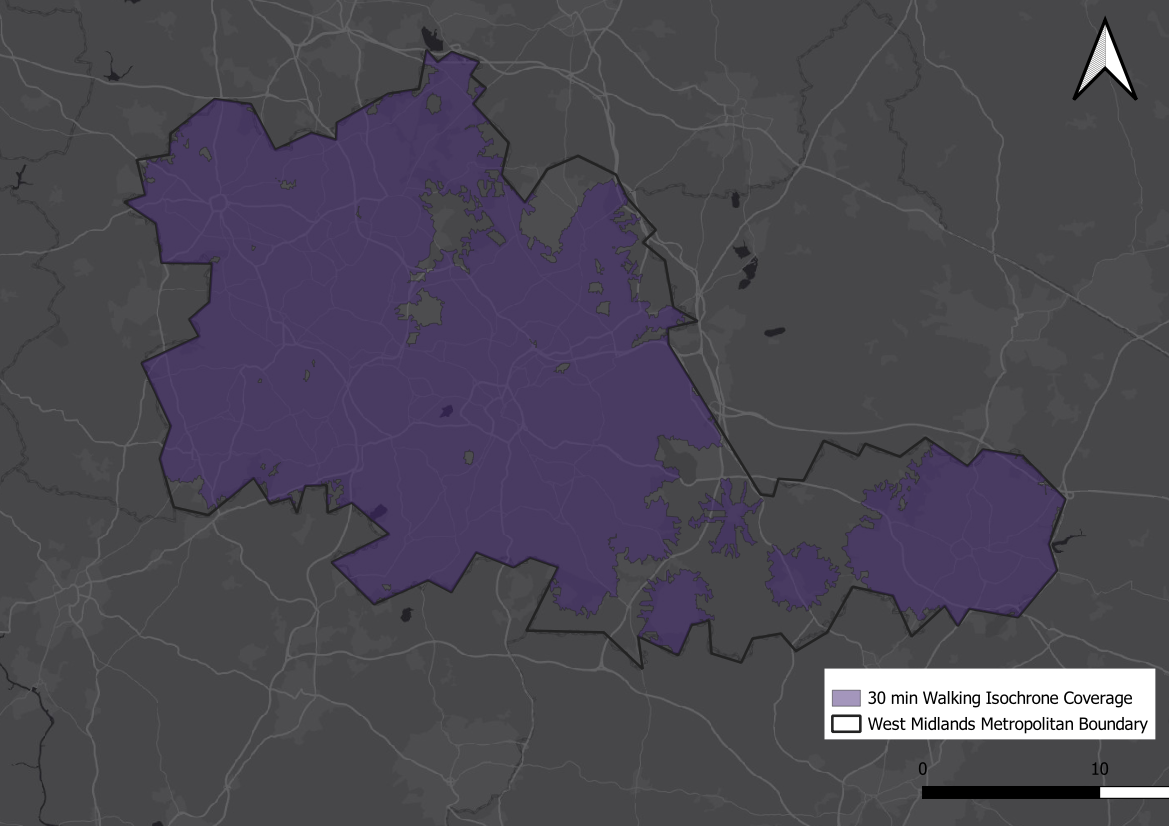

# **Machine Learning**

In [14]:
lsoa_gdf = lsoa_boundary.to_crs("EPSG:27700")

# Spatial join: Find which LSOA each point falls into
joined_gdf = gpd.sjoin(gdf, lsoa_gdf, how='left', predicate='intersects')

# Filter out rows where lsoa_cd is NaN
filtered_gdf = joined_gdf[joined_gdf['lsoa_cd'].notna()]
merged_gdf = filtered_gdf.merge(gp_data, left_on='PRACTICE_CODE', right_on='CODE', how='inner')
# Select the specified columns from the merged GeoDataFrame
final_gdf = merged_gdf[['PRACTICE_CODE', 'PRACTICE_NAME', 'lsoa_id', 'lad_nm', 'NUMBER_OF_PATIENTS']]

pop_merge = final_gdf.merge(pop, left_on='lsoa_id', right_on='LSOA 2021 Code', how='left')
pop_output = pop_merge[['PRACTICE_CODE', 'PRACTICE_NAME', 'lsoa_id', 'lad_nm', 'NUMBER_OF_PATIENTS', '2022_pop','2022_den']]
print(pop_output.head())

  PRACTICE_CODE               PRACTICE_NAME    lsoa_id      lad_nm  \
0        M84012  PARK LEYS MEDICAL PRACTICE  E01009524    Coventry   
1        M85001          SHAH ZAMAN SURGERY  E01009101  Birmingham   
2        M85002    HANDSWORTH WOOD MED.CTR.  E01009265  Birmingham   
3        M85005     THE PARK MEDICAL CENTRE  E01009337  Birmingham   
4        M85006         GREEN RIDGE SURGERY  E01008932  Birmingham   

   NUMBER_OF_PATIENTS  2022_pop      2022_den  
0               16447      1506   2936.817473  
1                4822      1561   1335.215123  
2               17701      1857   7076.981707  
3                7721      1903  12495.075510  
4               10468      1688   4485.782620  


In [15]:
print("\n----------------------\n")
print("Dataframe Info:")
print("\n----------------------\n")
pop_output.info()
print("\n----------------------\n")

print("Dataframe Description:")
print("\n----------------------\n")
print(pop_output.describe())
print("\n----------------------\n")



----------------------

Dataframe Info:

----------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PRACTICE_CODE       400 non-null    object 
 1   PRACTICE_NAME       400 non-null    object 
 2   lsoa_id             400 non-null    object 
 3   lad_nm              400 non-null    object 
 4   NUMBER_OF_PATIENTS  400 non-null    int64  
 5   2022_pop            400 non-null    int64  
 6   2022_den            400 non-null    float64
dtypes: float64(1), int64(2), object(4)
memory usage: 22.0+ KB

----------------------

Dataframe Description:

----------------------

       NUMBER_OF_PATIENTS     2022_pop      2022_den
count          400.000000   400.000000    400.000000
mean          8629.317500  1806.985000   5624.962138
std           7129.827715   390.472049   3116.848823
min             55.000000  1126.000000   

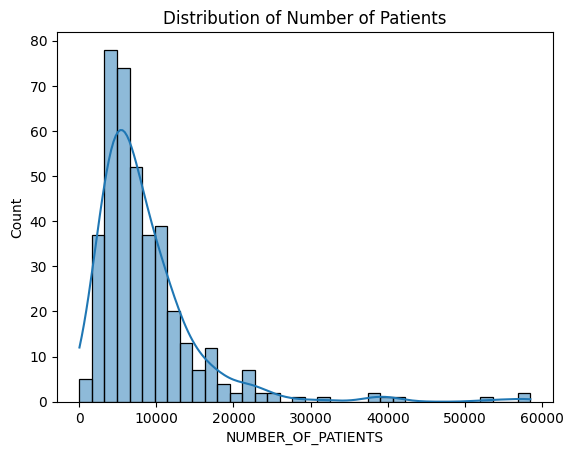

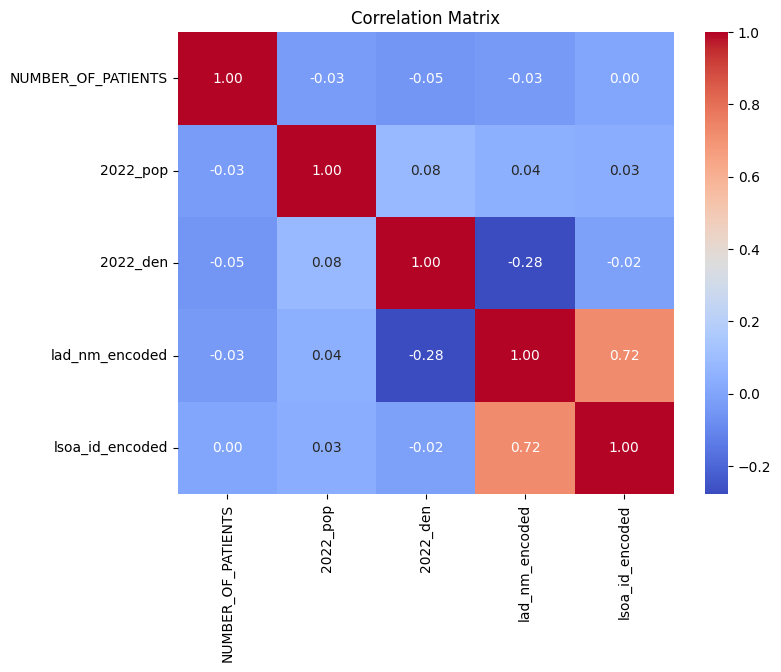

In [16]:
# Distribution of number_of_patients
sns.histplot(pop_output['NUMBER_OF_PATIENTS'], kde=True)
plt.title('Distribution of Number of Patients')

# Columns to keep
columns_to_keep = ['NUMBER_OF_PATIENTS', '2022_pop', '2022_den', 'lad_nm', 'lsoa_id']
df = pop_output[columns_to_keep]

# Label encode 'lad_nm' and 'lsoa_cd'
encoder_lad = LabelEncoder()
encoder_lsoa = LabelEncoder()

df['lad_nm_encoded'] = encoder_lad.fit_transform(df['lad_nm'])
df['lsoa_id_encoded'] = encoder_lsoa.fit_transform(df['lsoa_id'])

# Drop original categorical columns if desired
df = df.drop(columns=['lad_nm', 'lsoa_id'])

# Check the correlation matrix
correlation_matrix = df.corr()

# Visualize the correlation matrix


plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Text(0.5, 1.0, 'Patients vs Population Density')

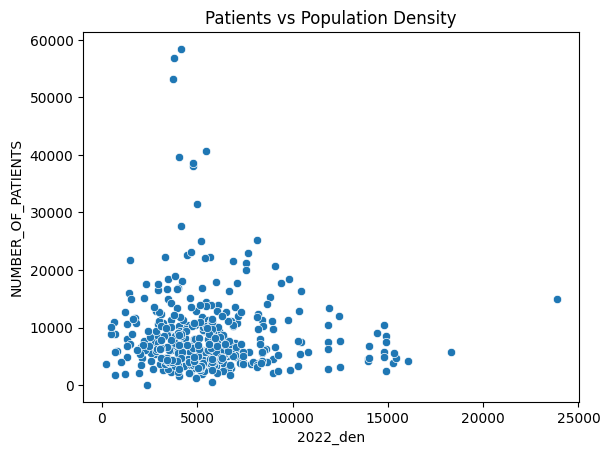

In [17]:
sns.scatterplot(data=df, x='2022_den', y='NUMBER_OF_PATIENTS')
plt.title('Patients vs Population Density')

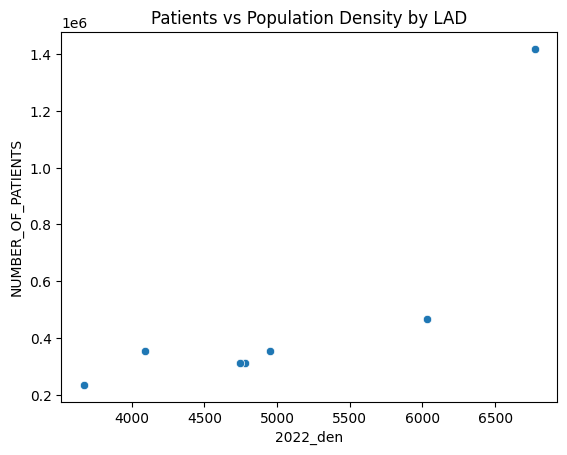

In [18]:
lad_grouped = df.groupby('lad_nm_encoded').agg({'NUMBER_OF_PATIENTS': 'sum', '2022_den': 'mean'}).reset_index()
sns.scatterplot(data=lad_grouped, x='2022_den', y='NUMBER_OF_PATIENTS')
plt.title('Patients vs Population Density by LAD')
plt.show()

In [19]:
# Check for negative values in the original population and density columns
print(df[['2022_pop', '2022_den']].describe())
print(df[df['2022_pop'] < 0])  # Check rows with negative population
print(df[df['2022_den'] < 0])  # Check rows with negative density

          2022_pop      2022_den
count   400.000000    400.000000
mean   1806.985000   5624.962138
std     390.472049   3116.848823
min    1126.000000    194.278523
25%    1536.750000   3674.737177
50%    1746.500000   5189.987937
75%    1975.500000   6647.728824
max    4562.000000  23854.748600
Empty DataFrame
Columns: [NUMBER_OF_PATIENTS, 2022_pop, 2022_den, lad_nm_encoded, lsoa_id_encoded]
Index: []
Empty DataFrame
Columns: [NUMBER_OF_PATIENTS, 2022_pop, 2022_den, lad_nm_encoded, lsoa_id_encoded]
Index: []


In [20]:
# Ensure there are no zeros in the 'NUMBER_OF_PATIENTS' column to avoid division by zero
df['NUMBER_OF_PATIENTS'] = df['NUMBER_OF_PATIENTS'].replace(0, 1)  # Replace zero with 1

# Calculate the 'pop_per_gp' (population per GP practice) and 'density_ratio' (density per population)
df['pop_per_gp'] = df['2022_pop'] / df['NUMBER_OF_PATIENTS']
df['density_ratio'] = df['2022_den'] / df['2022_pop']

# Handle any NaN or infinite values that might have appeared during the calculations
df['pop_per_gp'] = df['pop_per_gp'].replace([float('inf'), -float('inf')], 0)
df['density_ratio'] = df['density_ratio'].replace([float('inf'), -float('inf')], 0)

# Check if there are any NaN values, and handle them (e.g., by replacing with the mean or median)
df[['pop_per_gp', 'density_ratio']] = df[['pop_per_gp', 'density_ratio']].fillna(df[['pop_per_gp', 'density_ratio']].mean())

# Display the head of the dataframe to check results
print(df.head())

   NUMBER_OF_PATIENTS  2022_pop      2022_den  lad_nm_encoded  \
0               16447      1506   2936.817473               1   
1                4822      1561   1335.215123               0   
2               17701      1857   7076.981707               0   
3                7721      1903  12495.075510               0   
4               10468      1688   4485.782620               0   

   lsoa_id_encoded  pop_per_gp  density_ratio  
0              109    0.091567       1.950078  
1               32    0.323725       0.855359  
2               62    0.104909       3.810976  
3               77    0.246471       6.565988  
4                7    0.161253       2.657454  


In [21]:
from sklearn.preprocessing import MinMaxScaler
# Ensure there are no zeros in the 'NUMBER_OF_PATIENTS' column to avoid division by zero
df['NUMBER_OF_PATIENTS'] = df['NUMBER_OF_PATIENTS'].replace(0, 1)  # Replace zero with 1

# Calculate the 'pop_per_gp' (population per GP practice) and 'density_ratio' (density per population)
df['pop_per_gp'] = df['2022_pop'] / df['NUMBER_OF_PATIENTS']
df['density_ratio'] = df['2022_den'] / df['2022_pop']

# Handle any NaN or infinite values that might have appeared during the calculations
df['pop_per_gp'] = df['pop_per_gp'].replace([float('inf'), -float('inf')], 0)
df['density_ratio'] = df['density_ratio'].replace([float('inf'), -float('inf')], 0)

# Check if there are any NaN values, and handle them (e.g., by replacing with the mean or median)
df[['pop_per_gp', 'density_ratio']] = df[['pop_per_gp', 'density_ratio']].fillna(df[['pop_per_gp', 'density_ratio']].mean())

# Apply MinMaxScaler to scale only the computed features
scaler = MinMaxScaler()
df[['pop_per_gp', 'density_ratio']] = scaler.fit_transform(df[['pop_per_gp', 'density_ratio']])

# Display the head of the dataframe to check results
print(df.head())

   NUMBER_OF_PATIENTS  2022_pop      2022_den  lad_nm_encoded  \
0               16447      1506   2936.817473               1   
1                4822      1561   1335.215123               0   
2               17701      1857   7076.981707               0   
3                7721      1903  12495.075510               0   
4               10468      1688   4485.782620               0   

   lsoa_id_encoded  pop_per_gp  density_ratio  
0              109    0.001785       0.167547  
1               32    0.008324       0.069141  
2               62    0.002160       0.334825  
3               77    0.006148       0.582476  
4                7    0.003748       0.231134  


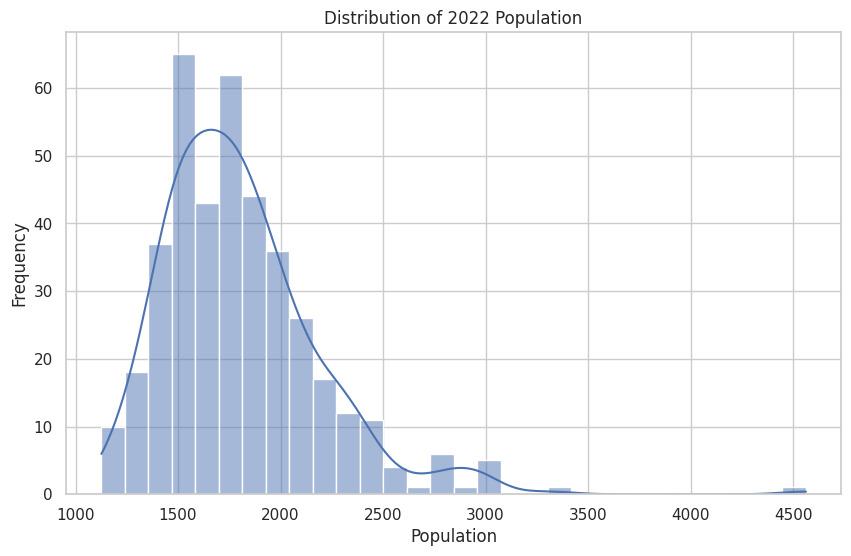

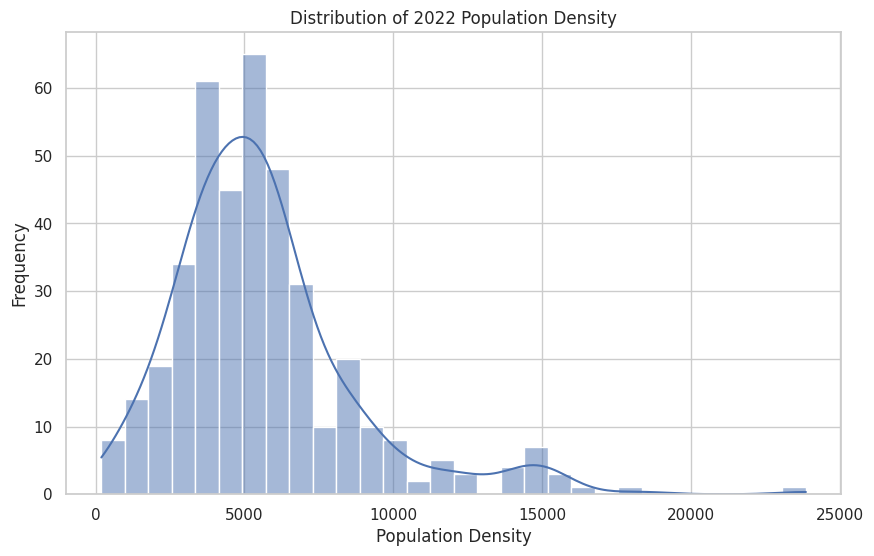

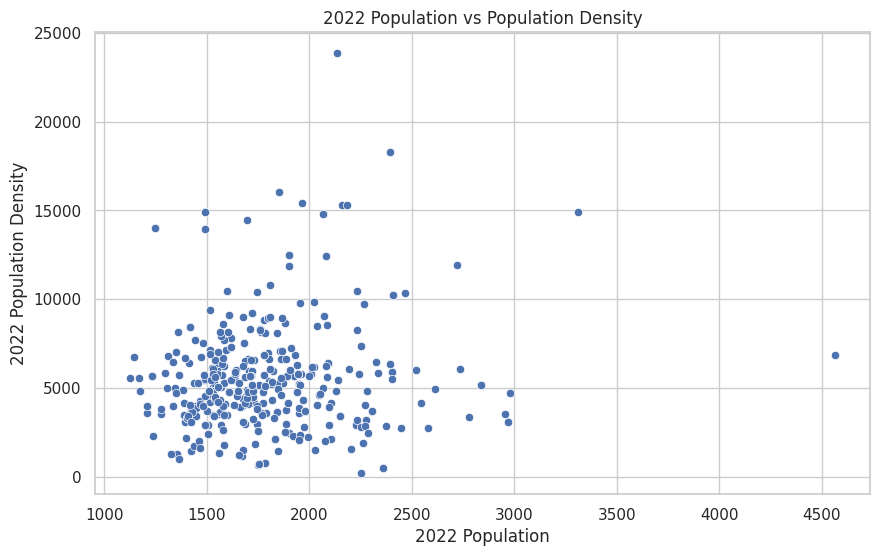

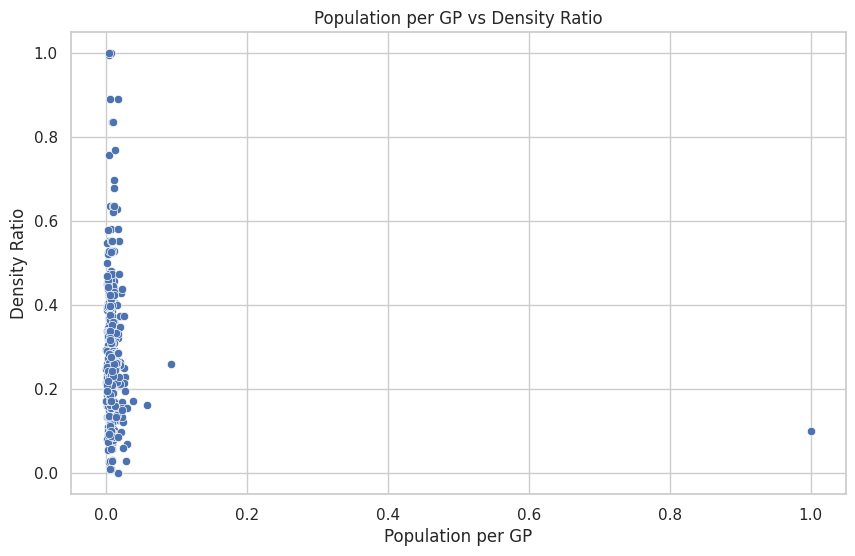

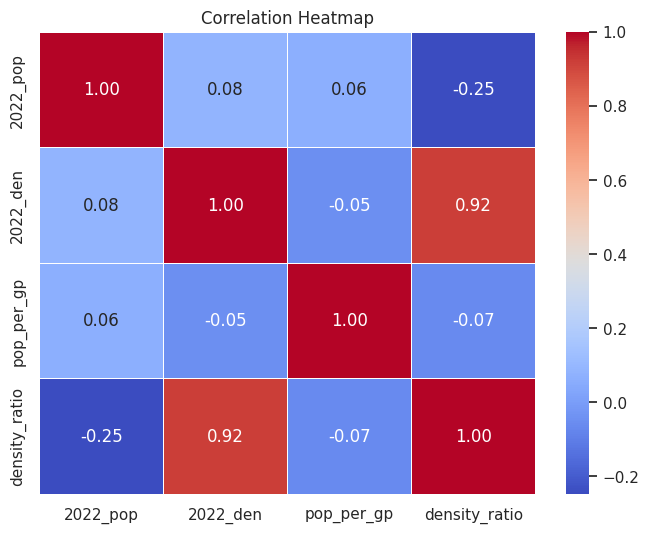

In [22]:
# Set the style for better visuals
sns.set(style="whitegrid")

# 1. Distribution of 2022 population
plt.figure(figsize=(10, 6))
sns.histplot(df['2022_pop'], kde=True, bins=30)
plt.title('Distribution of 2022 Population')
plt.xlabel('Population')
plt.ylabel('Frequency')
plt.show()

# 2. Distribution of 2022 density
plt.figure(figsize=(10, 6))
sns.histplot(df['2022_den'], kde=True, bins=30)
plt.title('Distribution of 2022 Population Density')
plt.xlabel('Population Density')
plt.ylabel('Frequency')
plt.show()

# 3. Scatter plot between 2022 population and density
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['2022_pop'], y=df['2022_den'])
plt.title('2022 Population vs Population Density')
plt.xlabel('2022 Population')
plt.ylabel('2022 Population Density')
plt.show()

# 4. Scatter plot between Population per GP and Density Ratio
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['pop_per_gp'], y=df['density_ratio'])
plt.title('Population per GP vs Density Ratio')
plt.xlabel('Population per GP')
plt.ylabel('Density Ratio')
plt.show()

# 5. Correlation heatmap between the features
corr_matrix = df[['2022_pop', '2022_den', 'pop_per_gp', 'density_ratio']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [23]:
# Features and target
X = df[['2022_pop', '2022_den', 'pop_per_gp', 'density_ratio', 'lad_nm_encoded', 'lsoa_id_encoded']]
y = df['NUMBER_OF_PATIENTS']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Mean Squared Error: 16910853.1996575
R² Score: 0.8526584273475281


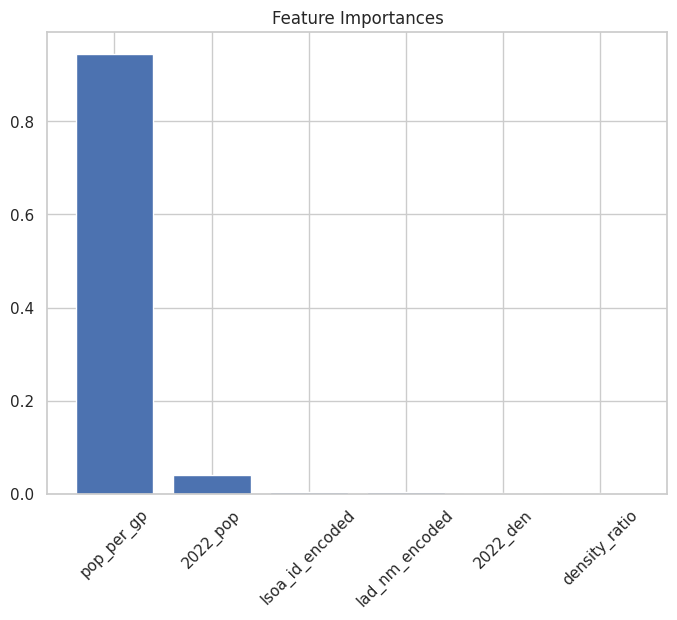

In [24]:

# Train the model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

# Feature importance

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.title("Feature Importances")
plt.show()


In [25]:


xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 11477845.0
R² Score: 0.8999953866004944


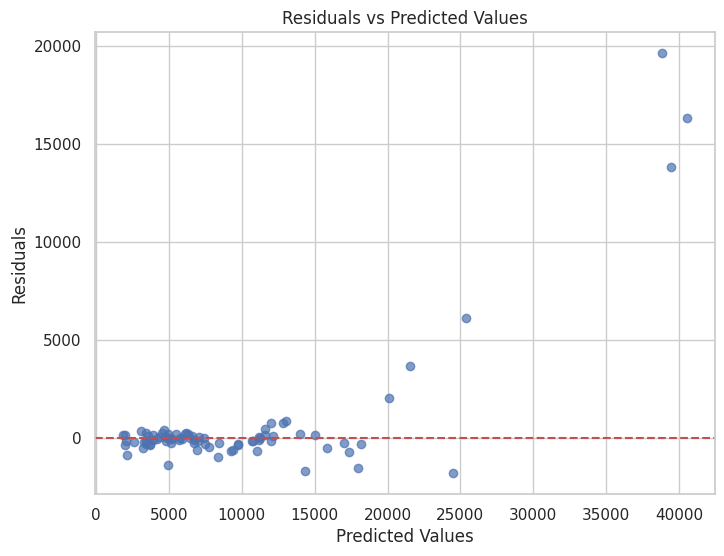

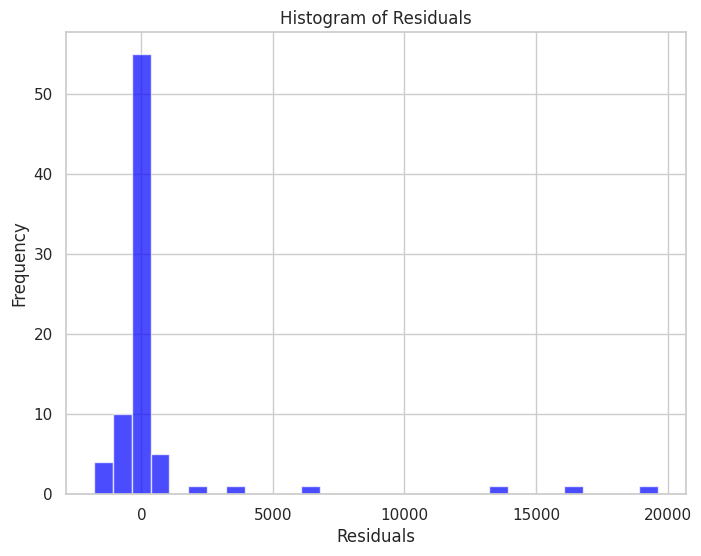

In [26]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


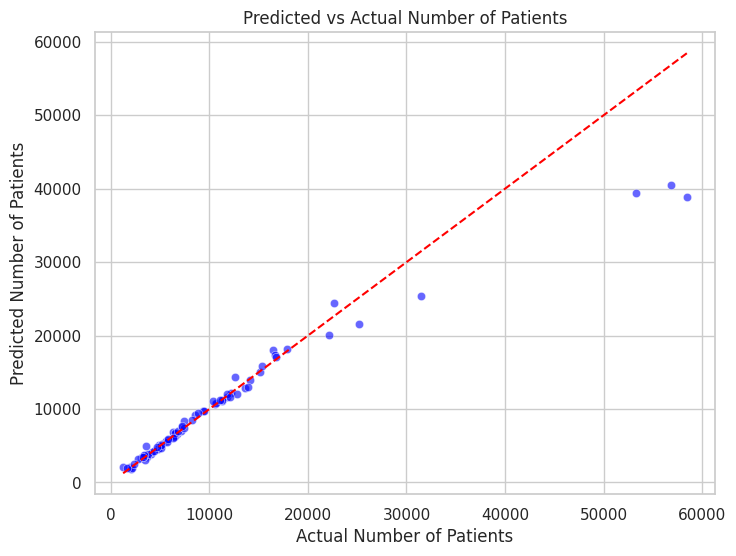

In [27]:
# Scatter plot of predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors="w", linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # 45-degree line
plt.title('Predicted vs Actual Number of Patients')
plt.xlabel('Actual Number of Patients')
plt.ylabel('Predicted Number of Patients')
plt.grid(True)
plt.show()

In [28]:
df.head()

,NUMBER_OF_PATIENTS,2022_pop,2022_den,lad_nm_encoded,lsoa_id_encoded,pop_per_gp,density_ratio
0,16447,1506,2936.817473,1,109,0.001785,0.167547
1,4822,1561,1335.215123,0,32,0.008324,0.069141
2,17701,1857,7076.981707,0,62,0.002160,0.334825
3,7721,1903,12495.075510,0,77,0.006148,0.582476
4,10468,1688,4485.782620,0,7,0.003748,0.231134


# **Machine Learning Accuracy**

Random Forest: 85%  
XGB: 90%

In [35]:
# Create the prediction DataFrame with all test features
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
pred_data = X_test.copy()
pred_data['Actual'] = y_test
pred_data['Predicted'] = y_pred
pred_data['% Variation'] = [(abs(a - p) / a) * 100 for a, p in zip(y_test, y_pred)]

print("Original Predictions:")
print(pred_data)

Original Predictions:
    2022_pop      2022_den  pop_per_gp  density_ratio  lad_nm_encoded  \
0       1724   4483.745124    0.001347       0.226039               2   
1       1727   3255.419416    0.004871       0.161698               4   
2       1840   3637.082427    0.003819       0.169938               0   
3       1449   3408.609739    0.007520       0.203711               2   
4       1570   2930.744820    0.003381       0.160053               0   
..       ...           ...         ...            ...             ...   
75      1688   2978.122795    0.003504       0.150846               3   
76      1563   4320.066335    0.012686       0.240707               2   
77      1864   6607.585962    0.008186       0.310902               6   
78      1248  13991.031390    0.006707       1.000000               1   
79      1884   3765.740556    0.000138       0.171926               4   

    lsoa_id_encoded  Actual     Predicted  % Variation  
0               164   22674  24461.046875   

In [36]:
# Simulate a population change for a specific LSOA
lsoa_to_change = 104  # Example: Change population for LSOA 104
new_population = 800  # New population value

# Modify the feature and predict new patient numbers
pred_data_simulated = pred_data.copy()
pred_data_simulated.loc[pred_data_simulated['lsoa_id_encoded'] == lsoa_to_change, '2022_pop'] = new_population
X_simulated = pred_data_simulated[['2022_pop', '2022_den', 'pop_per_gp', 'density_ratio', 'lad_nm_encoded', 'lsoa_id_encoded']]
pred_data_simulated['New Predicted'] = xgb_model.predict(X_simulated)

print("\nPredictions After Population Change:")
print(pred_data_simulated)


Predictions After Population Change:
    2022_pop      2022_den  pop_per_gp  density_ratio  lad_nm_encoded  \
0       1724   4483.745124    0.001347       0.226039               2   
1       1727   3255.419416    0.004871       0.161698               4   
2       1840   3637.082427    0.003819       0.169938               0   
3       1449   3408.609739    0.007520       0.203711               2   
4       1570   2930.744820    0.003381       0.160053               0   
..       ...           ...         ...            ...             ...   
75      1688   2978.122795    0.003504       0.150846               3   
76      1563   4320.066335    0.012686       0.240707               2   
77      1864   6607.585962    0.008186       0.310902               6   
78      1248  13991.031390    0.006707       1.000000               1   
79      1884   3765.740556    0.000138       0.171926               4   

    lsoa_id_encoded  Actual     Predicted  % Variation  New Predicted  
0            

In [48]:
# Filter for LSOA 104 before the population change
lsoa_to_change = 104  # Target LSOA ID
new_population = 800  # New population value

# Create a subset for LSOA 104 in the original dataset
original_lsoa = df[df['lsoa_id_encoded'] == lsoa_to_change].copy()

# Extract the previous actual value
previous_actual = original_lsoa['NUMBER_OF_PATIENTS'].values[0]

# Prepare the features for the original prediction
X_original = original_lsoa[['2022_pop', '2022_den', 'pop_per_gp', 'density_ratio', 'lad_nm_encoded', 'lsoa_id_encoded']]

# Predict the original number of patients
original_lsoa['Predicted'] = xgb_model.predict(X_original)

# Modify the population value to simulate the change
original_lsoa['2022_pop'] = new_population  # Use new population but column name remains '2022_pop'

# Prepare the features for the new prediction (with updated population)
X_simulated = original_lsoa[['2022_pop', '2022_den', 'pop_per_gp', 'density_ratio', 'lad_nm_encoded', 'lsoa_id_encoded']]

# Predict new patient numbers with the updated population
original_lsoa['New Predicted'] = xgb_model.predict(X_simulated)

# Create the final table with relevant columns
result = original_lsoa[['lsoa_id_encoded', '2022_pop', 'NUMBER_OF_PATIENTS', 'Predicted', 'New Predicted']]
result['Previous Actual'] = previous_actual

# Display the result
mod_result =result[['lsoa_id_encoded', 'Previous Actual', '2022_pop', 'Predicted', 'New Predicted']]

# Rename '2022_pop' to 'new_pop' in the mod_result DataFrame
mod_result.rename(columns={'2022_pop': 'new_pop'}, inplace=True)
print(mod_result)


    lsoa_id_encoded  Previous Actual  new_pop     Predicted  New Predicted
22              104            17876      800  18186.265625   14950.831055
